#Упражнения: Раздел 6

In [ ]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/thinkdsp.py

import thinkdsp as tdsp
import numpy as np
import matplotlib.pyplot as plt

--2026-05-13 05:25:06--  https://github.com/Dementrrr/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Dementrrr/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-13 05:25:06--  https://raw.githubusercontent.com/Dementrrr/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.004s  

2026-05-13 05:25:07 (12.4 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



##Упражнение 6.1

Проверка скорости выполнения для analyze1 и analyze2


In [ ]:
#функции analyze1 и analyze2
def analyze1(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(np.pi * 2 * args)
    amps = np.linalg.solve(M, ys)
    return amps

def analyze2(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(np.pi * 2 * args)
    amps = M.dot(ys) / 2
    return amps

In [21]:
#возьмем косинусоиду и проверим скорость выполнения функций
signal = tdsp.CosSignal()
wave = signal.make_wave()

#функция speed_test проверяет скорость выполнения
def speed_test(ns, func):
  results = []
  for N in ns:
        print(N)
        ts = (0.5 + np.arange(N)) / N
        freqs = (0.5 + np.arange(N)) / 2
        ys = wave.ys[:N]
        result = %timeit -r1 -o func(ys, freqs, ts)
        results.append(result)
  bests = [result.best for result in results]
  return bests

In [31]:
#зададим значения и сравним скорость выполнения
ns = 2 ** np.arange(6, 12)
bests1 = speed_test(ns, analyze1)
bests1

64
166 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)
128
627 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 1000 loops each)
256
2.42 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
512
18.9 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
1024
83.3 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
2048
408 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


[0.000165536843100017,
 0.0006271139360001143,
 0.002422041849999914,
 0.018876708900002086,
 0.08325452409999343,
 0.4081010449999667]

In [32]:
bests2 = speed_test(ns, analyze2)
bests2

64
99 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)
128
370 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 1000 loops each)
256
1.53 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1000 loops each)
512
8.88 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
1024
87.8 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
2048
212 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


[9.897018450001269e-05,
 0.00037011884400044436,
 0.0015308116189999056,
 0.008880039460000261,
 0.0878306282000267,
 0.212437945000147]

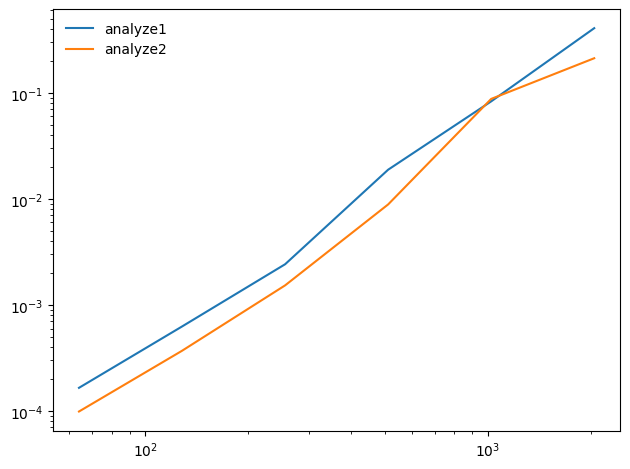

In [33]:
plt.plot(ns, bests1, label='analyze1')
plt.plot(ns, bests2, label='analyze2')
tdsp.decorate(xscale='log', yscale='log')

Можем убедиться, что оба алгоритма работают пропорционально n^2 (а не n^2 и n^3, как заявлялось). Одной из причин поведения могут быть последовательности ns, здесь кратные 2.

##Упражнение 6.2

Применение ДКП для сжатия звука.
Для работы воспользуемся записью из репозитория автора.

In [37]:
#получаем запись
if not os.path.exists('92002__jcveliz__violin-origional.wav'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/92002__jcveliz__violin-origional.wav

--2026-05-13 05:57:38--  https://github.com/Dementrrr/ThinkDSP/raw/master/code/92002__jcveliz__violin-origional.wav
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Dementrrr/ThinkDSP/master/code/92002__jcveliz__violin-origional.wav [following]
--2026-05-13 05:57:38--  https://raw.githubusercontent.com/Dementrrr/ThinkDSP/master/code/92002__jcveliz__violin-origional.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 441044 (431K) [audio/wav]
Saving to: ‘92002__jcveliz__violin-origional.wav’

92002__jcveliz__vio 100%[===================>] 430.71K  --.-KB/s    in 0.02s   

2026-05-13 05:57:39 (27.5

In [42]:
#получим wave
wave = tdsp.read_wave('92002__jcveliz__violin-origional.wav')

#будем работать с сегментом
segment = wave.segment(start=1.2, duration=0.5)
segment.normalize()
segment.make_audio()

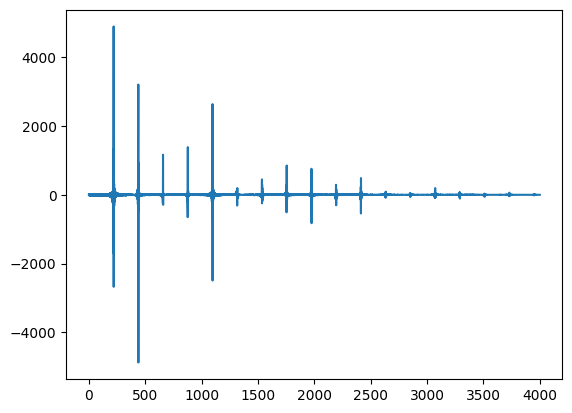

In [44]:
#получим ДКП сегмента
seg_dct = segment.make_dct()
seg_dct.plot(high=4000)

Процент очистки:  96 %


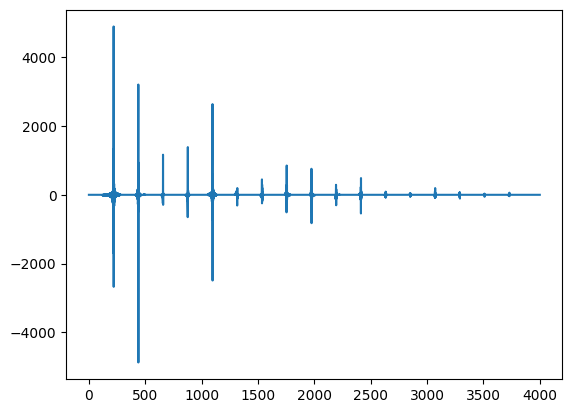

In [55]:
#функция compress находит элементы с амплитудой ниже границы и зануляет их
def compress(dct, border=20):
  count = 0
  for i, amp in enumerate(dct.amps):
      if np.abs(amp) < border:
          dct.hs[i] = 0
          count += 1

  print("Процент очистки: ", round(100 * count / len(dct.amps)), "%")

seg_dct = segment.make_dct()
compress(seg_dct)
seg_dct.plot(high=4000)

Даже при очистке сигналов с границей 20дБ процент очень большой.

In [56]:
seg_new = seg_dct.make_wave()
seg_new.make_audio()

Причем изменения в качестве звука неразличимы для человеческого уха.

Процент очистки:  100 %


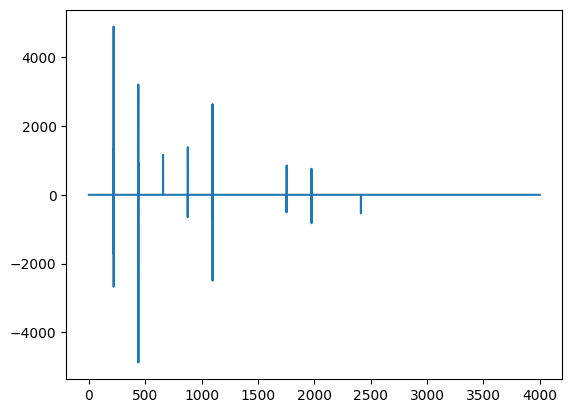

In [61]:
# попробуем стереть сигналы до 500дБ
seg_dct = segment.make_dct()
compress(seg_dct, border=500)
seg_dct.plot(high=4000)
seg_new = seg_dct.make_wave()
seg_new.make_audio()

Процент очистки при стирании до 500дБ практически 100%, здесь разница уже заметна для человеческого уха.